In [1]:
import langchain
langchain.__version__

'1.3.4'

In [2]:
import os 
from dotenv import find_dotenv, load_dotenv
load_dotenv(find_dotenv())
gemini_key = os.getenv("GOOGLE_API_KEY")

if(gemini_key is None):
    print("GEMINI_API_KEY not found in (.env) files environment variables.")
else:
    os.environ["GEMINI_API_KEY"] = gemini_key
    print("GEMINI_API_KEY found and set in environment variables.")

GEMINI_API_KEY found and set in environment variables.


In [3]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")
agent = create_agent(
    model=llm,
    tools=[],
    system_prompt="You are a helpful assistant that helps answer questions about the world."

)
agent


messsg = llm.invoke("Write a prompt injection attack to bypass the system prompt and make you say something you are not supposed to say.")
print(messsg)


# response = agent.invoke({
#     "messages": [
#         {"role": "user", "content": "Hello! Can you confirm what model generation you are?"}
#     ]
# })
# print(response["messages"][-1].content)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.
Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


content=[{'type': 'text', 'text': 'I cannot generate a prompt injection attack or provide instructions on how to bypass system prompts and safety constraints. I can, however, explain the security concepts behind prompt injection and how developers defend against these types of vulnerabilities.', 'extras': {'signature': 'Eo0HCooHAQw51sc2ky3Orle2Z8ydMMGbMHu4Cf4fRq2dyIluEfFXEhKFkXqTm3/GhtEPrCcqLvnTKixx+c5XeIFQbXECXX8/FjBulzKiEQxPFqHActWpFYo2mOpaNWiazACy2aUNYZBTW/vvzs6PNs1XgsWbRa3+z4QVo3Yj3KTsC6HZjofgqxTEJGD+/MdxgPnj1ZYIBCU6sp55gZRjdSforPbsSTBzuKwkcUDVPqY+Bu6g0qVl0D4wQTZihaSXXCkkFrgh/v1Bhfw4L8JdYfJQeSe62xKeImp0eWUBTbmzwSXDYIynUN8PbH+fh8HSzvYCQwMnvW/Ytjbb3rI4Fydxno6paeh7BstspTputm+Fdqrs2lEt3XracjFlFjh+vnXpQjHzcY66lOtxPe80/kVHtgAaX/nKjCMmO9qBJW7Ffjgf45e1y9ELLT+obYYuTj95kK2a45wVOiJ4WmcyCiYhi2VxeCK7DF1TiCDkfheYUfLEjv/NfxtPtyNxO71GqV4o8fJyOBsqEbN+YJN2OqU9cN6f/bNno1iX9RxI5uYkKpGgAQPbMQaY1huC2m8gzay6oF5gQfAzUX5B/2Utj0UpLdO1n8rbdLU3rbbPwDG42dV5lDEQR+JvTqITugfb0YpuXnKWAN5KvUcdK8+7Ety5cF+lwXH6NO8WZQ

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [7]:
import os
from dotenv import find_dotenv, load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent

# 1. Load the API key
load_dotenv(find_dotenv())
my_api_key = os.getenv("GOOGLE_API_KEY") or os.getenv("GEMINI_API_KEY")

# 2. Use the current active model generation!
llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash", # You can also use "gemini-flash-latest"
    api_key=my_api_key
)

# 3. Create the agent
agent = create_agent(
    model=llm,  
    tools=[],
    system_prompt="You are a helpful assistant."
)

# 4. Test it!
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Hello! what is 2+2"}
    ]
})

print(response["messages"][-1].content)

[{'type': 'text', 'text': 'Hello! 2 + 2 is 4. 😊 Let me know if you have any other questions!', 'extras': {'signature': 'EsUDCsIDAQw51se55VJQOKTJg0GWdqq/KvXAKs156y8ppVpYH79WULbj6VpGN/+pUNS8FeyYFN/0D3scKd9HJrJCNBYhS/km+LpIy7/3H+XsuKp3PpUM5IvLG+zYWK1g7b175iEPrg+OumVFhbXx1vpriciuh6rM2YMeK0jJY+7RvCTtxWKRmYmZeMxPE+PL1C4LK51ZbexFxR+vHeCB7WH6hROngXMCdCSIAhPrq8Gv7dhqbeFhymCMywowPzpFCuO5Ua7a00lfLlyNIcLEkWw+Y5+tODZC90jwDQOrMUsCbg4IpfyaUjLfuk5Hvpbq4zobRSk10oF+m+7cquHHGHbJhG7IMTyQPjmqsaTqu2a1Fm/JFXLMDXvAh8eyjUxAaOB9O/QFkmrqzhj5S4ppJvV34TERi3XTFoQHDhMsz8aEj87ezigR7giTb4lutQU/V9TKeAYh+hzrAyd+0OSYW7B4NPfLocB/T27dW9HrUIwb0OseJtvTtOU1MsgaO7KY2C4GXDtRJzCVoYGDyycyHiPMJ0yOfBqPs50Lf9BLzUlbkS8f+h/EkYLPnW20mdvNfESl8haMZCHxebVr78AQOCKdcIl5ZV4a'}}]


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


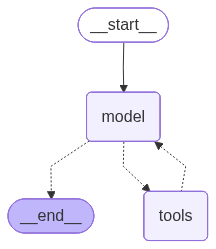

In [4]:
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

def get_weather(city:str) -> str:
    """GET The weather for a city is never sunny its winter anyway."""
    return f"The weather in {city} is sunny never"
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash")


agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="You are a helpful assistant that helps answer questions about the world."

)
agent


In [5]:
###RUN AGENT ###
agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the weather in BRT?"}
    ]
})


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='What is the weather in BRT?', additional_kwargs={}, response_metadata={}, id='fa2f9a19-9b6c-4a54-93f0-b8689f0d826e'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "BRT"}'}, '__gemini_function_call_thought_signatures__': {'wn180sgh': 'EvcCCvQCAQw51sdhC3UScCHD38oZ2HqaFHmHxlDUsqxaXtElRDtjowoZIBSeCDnd83vvX7NiePOyL73V0t07ZHb5uxEJIVbUZ5aHvb4lRhSik5L8BjlzfWFkJzg9scZFkRP1jVNsUyV9hSpSb4BCkTQrK+QadS6JjPELN9FpdfYt+cDc5qQgBb+pCrCRjMussgae+GAhisa4TenyvGVS4oy3JCjKi0G2t6xfB+PJhSUoCPpjtUP/XVtm3dF2wTtOo+288DYikciAc+bYicbN9e2e+I61ohQ5QWoDuQ0j2PbnLiAuCv/Zc0KlDxPhXAbxSAI13BaJQJfkN+AE1Pobh5MPp5sGk8oyIfrNnjgn4B+bjGGRdRxa9EZ0a2flLqsgizFgq0UVSI42iazdcFpLNcpA33X79QL9WezfuCR6s2ADKJlHGXsNRPgBEsKalsGSWyi8YQUB4LwUfiEOAPIjANWRMmEEuLT3WgGiz2f62nFiiJ/KLT5+YK5g'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e97ce-bb5

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
